In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import joblib
import emoji

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [8]:
df = pd.read_csv("../data/tweet.csv")

df.head

<bound method NDFrame.head of                   Name                                  Tweet description
0         Barack Obama  We're seeing the fastest rise in sea-levels in...
1         Barack Obama  RT @WhiteHouse: Watch @POTUS and @FLOTUS share...
2         Barack Obama  See what editorial boards are saying about Sen...
3         Barack Obama  President Obama is at the @CopernicusCtr in Ch...
4         Barack Obama  LIVE: President Obama is answering questions f...
...                ...                                                ...
18675  Sebastian Ruder  @EmilStenstrom Are you using Firefox? Someone ...
18676  Sebastian Ruder  @KieranSnyder The following are some interesti...
18677  Sebastian Ruder  The initial work on casting NLP tasks as QA (h...
18678  Sebastian Ruder  New NLP News - Paperclip maximizer, Generative...
18679  Sebastian Ruder  RT @jeremyjordan: How to Write a 💯 Research Pa...

[18680 rows x 2 columns]>

In [9]:
df.shape

(18680, 2)

In [10]:
df.columns

Index(['Name', 'Tweet description'], dtype='str')

In [11]:
df.info

<bound method DataFrame.info of                   Name                                  Tweet description
0         Barack Obama  We're seeing the fastest rise in sea-levels in...
1         Barack Obama  RT @WhiteHouse: Watch @POTUS and @FLOTUS share...
2         Barack Obama  See what editorial boards are saying about Sen...
3         Barack Obama  President Obama is at the @CopernicusCtr in Ch...
4         Barack Obama  LIVE: President Obama is answering questions f...
...                ...                                                ...
18675  Sebastian Ruder  @EmilStenstrom Are you using Firefox? Someone ...
18676  Sebastian Ruder  @KieranSnyder The following are some interesti...
18677  Sebastian Ruder  The initial work on casting NLP tasks as QA (h...
18678  Sebastian Ruder  New NLP News - Paperclip maximizer, Generative...
18679  Sebastian Ruder  RT @jeremyjordan: How to Write a 💯 Research Pa...

[18680 rows x 2 columns]>

In [12]:
df.isnull().sum()

Name                 0
Tweet description    0
dtype: int64

In [13]:
df["Name"].value_counts()

Name
Barack Obama           2585
Neil deGrasse Tyson    2525
Ellen DeGeneres        2457
Sebastian Ruder        2374
KATY PERRY             2326
Elon Musk              2232
Kim Kardashian West    2149
Cristiano Ronaldo      2032
Name: count, dtype: int64

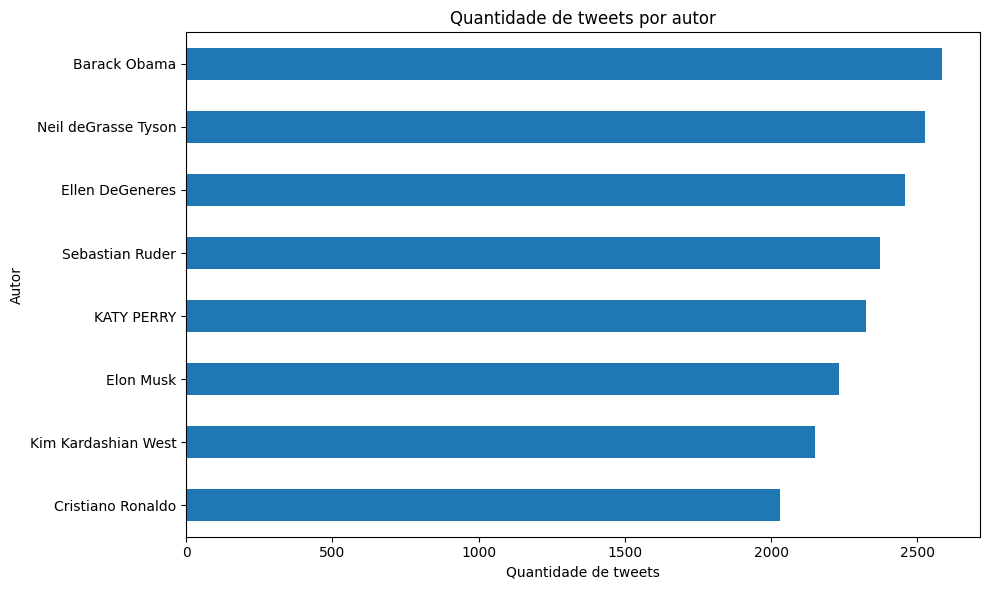

In [16]:
plt.figure(figsize=(10, 6))
df["Name"].value_counts().sort_values().plot(kind="barh")
plt.title("Quantidade de tweets por autor")
plt.xlabel("Quantidade de tweets")
plt.ylabel("Autor")
plt.tight_layout()
plt.show()

In [19]:
df["num_words_raw"] = df["Tweet description"].astype(str).apply(lambda x: len(x.split()))

df[["Name", "Tweet description", "num_words_raw"]].head()

,Name,Tweet description,num_words_raw
0,Barack Obama,We're seeing the fastest rise in sea-levels in...,13
1,Barack Obama,RT @WhiteHouse: Watch @POTUS and @FLOTUS share...,16
2,Barack Obama,See what editorial boards are saying about Sen...,18
3,Barack Obama,President Obama is at the @CopernicusCtr in Ch...,18
4,Barack Obama,LIVE: President Obama is answering questions f...,13


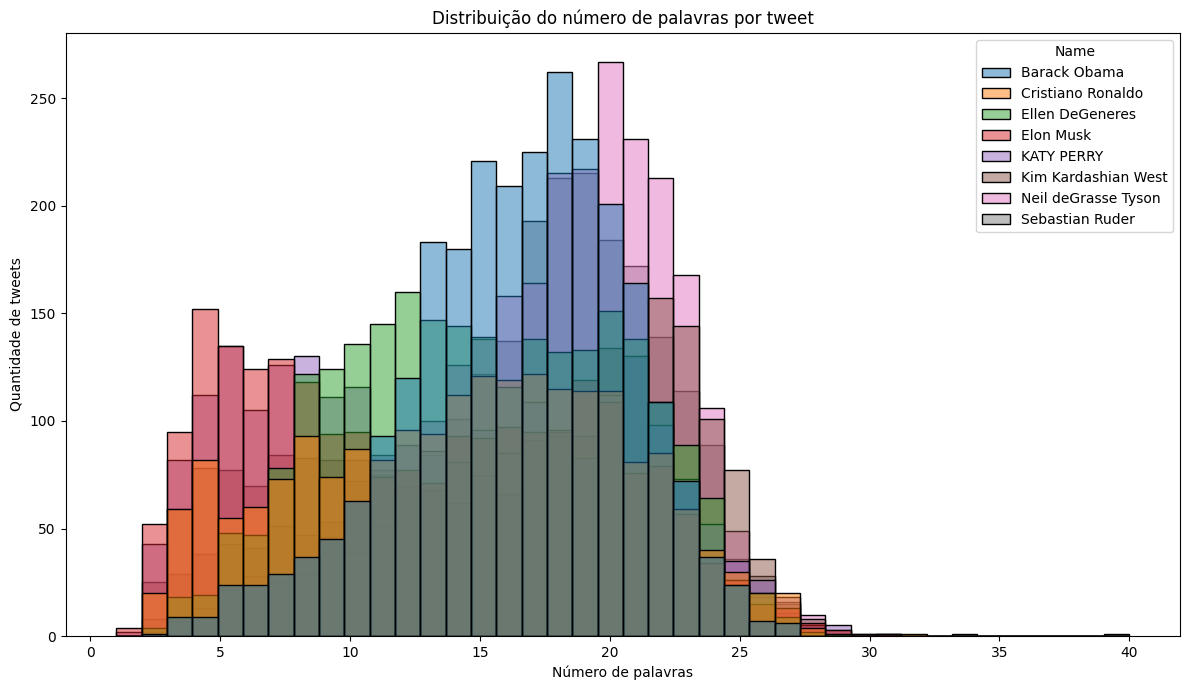

In [27]:
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x="num_words_raw", hue="Name", bins=40, kde=False)
plt.title("Distribuição do número de palavras por tweet")
plt.xlabel("Número de palavras")
plt.ylabel("Quantidade de tweets")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

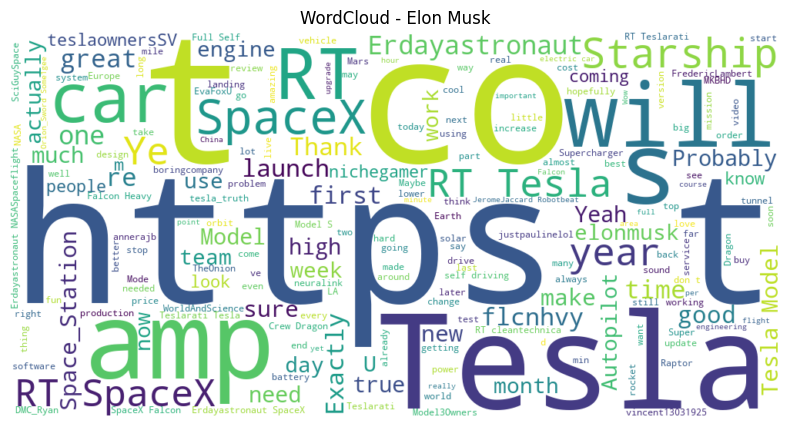

In [31]:
autor = "Elon Musk"
texto = " ".join(df[df["Name"] == autor]["Tweet description"].astype(str))
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(texto)

plt.figure (figsize=(12, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(f"WordCloud - {autor}")
plt.show


In [35]:
def limpar_texto(texto):
    texto = str(texto)
    texto =re.sub(r"http\S+|www\S+|https\S+", "", texto)
    texto = re.sub(r"@\w+", "", texto)
    texto = re.sub(r"#", "", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

In [42]:
df["tweet_limpo"] = df["Tweet description"].apply(limpar_texto)

df[["Tweet description", "tweet_limpo"]].head()

,Tweet description,tweet_limpo
0,We're seeing the fastest rise in sea-levels in...,We're seeing the fastest rise in sea-levels in...
1,RT @WhiteHouse: Watch @POTUS and @FLOTUS share...,RT : Watch and share their favorite Olympic me...
2,See what editorial boards are saying about Sen...,See what editorial boards are saying about Sen...
3,President Obama is at the @CopernicusCtr in Ch...,President Obama is at the in Chicago speaking ...
4,LIVE: President Obama is answering questions f...,LIVE: President Obama is answering questions f...


In [ ]:
df["num_words_clean"] = df["tweet_limpo"].apply(lambda x: len(x.split()))

df[["tweet_limpo", "num_words_clean"]].head()

KeyError: "['num_word_clean'] not in index"